#  Nigerian Real Estate Market Analysis

**Author:** Faith Aduloju
**Tools:** Python · Pandas · Matplotlib · Seaborn  
**Dataset:** 24,326 Nigerian property listings  

---

## Overview

This project performs an exploratory data analysis of the Nigerian residential 
property market using listings scraped from Nigerian real estate platforms. 
The goal is to uncover market trends and answer key business questions relevant 
to investors, developers, banks, and fintechs.

---

## Business Questions

| Category | Question |
|---|---|
| **Investment** | Where should I invest in Nigerian real estate? |
| **Investment** | Which property type gives the best value for money? |
| **Investment** | What is the average cost of entry into the market? |
| **Market** | Which states have the most active real estate markets? |
| **Market** | Is the market concentrated or spread across Nigeria? |
| **Market** | What is the price range — affordable vs luxury? |
| **Risk** | Are there outlier prices suggesting fraud or data errors? |
| **Risk** | How much price variation exists within each state? |
| **Developer** | What type of property should I build to maximize sales? |
| **Developer** | Which locations have the most demand? |

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Visual style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})


In [23]:
# formatting prices for easier readability
def naira_format(x, _):
    if x >= 1e12:
        return f"₦{x/1e12:.1f}T"
    elif x >= 1e9:
        return f"₦{x/1e9:.1f}B"
    elif x >= 1e6:
        return f"₦{x/1e6:.0f}M"
    else:
        return f"₦{x:,.0f}"

In [25]:
df = pd.read_csv("../data/nigeria_houses_data.csv")
print(df.shape)
df.info()

(24326, 8)
<class 'pandas.DataFrame'>
RangeIndex: 24326 entries, 0 to 24325
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       24326 non-null  float64
 1   bathrooms      24326 non-null  float64
 2   toilets        24326 non-null  float64
 3   parking_space  24326 non-null  float64
 4   title          24326 non-null  str    
 5   town           24326 non-null  str    
 6   state          24326 non-null  str    
 7   price          24326 non-null  float64
dtypes: float64(5), str(3)
memory usage: 1.5 MB


In [26]:
df.head()

,bedrooms,bathrooms,toilets,parking_space,title,town,state,price
0,6.0,5.0,5.0,4.0,Detached Duplex,Mabushi,Abuja,450000000.0
1,4.0,5.0,5.0,4.0,Terraced Duplexes,Katampe,Abuja,800000000.0
2,4.0,5.0,5.0,4.0,Detached Duplex,Lekki,Lagos,120000000.0
3,4.0,4.0,5.0,6.0,Detached Duplex,Ajah,Lagos,40000000.0
4,4.0,4.0,5.0,2.0,Semi Detached Duplex,Lekki,Lagos,75000000.0


## Data Cleaning

### Checking for missing values

In [27]:
df.isnull().sum() / len(df) * 100  # as percentages

bedrooms         0.0
bathrooms        0.0
toilets          0.0
parking_space    0.0
title            0.0
town             0.0
state            0.0
price            0.0
dtype: float64

### Handling Duplicates

In [28]:
print(f"Length of df:{len(df)}")
print(f"Sum of duplicates:{df.duplicated().sum()}")
print(f"Percentage of duplicates:{df.duplicated().sum()/len(df)*100}")

Length of df:24326
Sum of duplicates:10438
Percentage of duplicates:42.90882183671791


In [29]:
df=df.drop_duplicates()
print(f"length of df after dropping duplicates:{len(df)}")

length of df after dropping duplicates:13888


The dataset contained 10,438 duplicate entries (42.9%) — almost certainly caused by repeated scraping of property listings. All duplicates were removed, leaving 13,888 unique records.

### Removal of outlier prices suggesting fraud/errors.

In [30]:
df["price"].describe().apply("{:,.0f}".format)

count               13,888
mean           400,213,749
std         16,149,258,583
min                 90,000
25%             38,000,000
50%             75,000,000
75%            160,000,000
max      1,800,000,000,000
Name: price, dtype: str

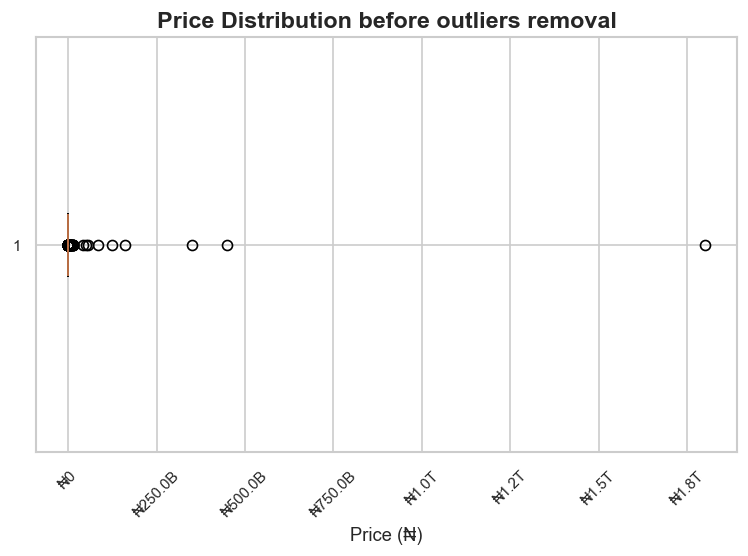

In [31]:
fig, ax = plt.subplots()
ax.boxplot(x=df["price"], vert=False)
ax.set_title("Price Distribution before outliers removal")
ax.set_xlabel("Price (₦)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(naira_format))
plt.xticks(rotation=45)
plt.tight_layout();
plt.savefig("../images/price_distribution_before_outlier_removal.png")

In [58]:
#Removing outliers
df=df[(df["price"]>=df["price"].quantile(0.01))&
              (df["price"]<=df["price"].quantile(0.99))]

In [59]:
df["price"].describe().apply("{:,.0f}".format)

count         12,944
mean     125,362,817
std      141,658,599
min       10,500,000
25%       40,000,000
50%       75,000,000
75%      150,000,000
max      850,000,000
Name: price, dtype: str

Text(0.5, 1.0, 'Skewness of price')

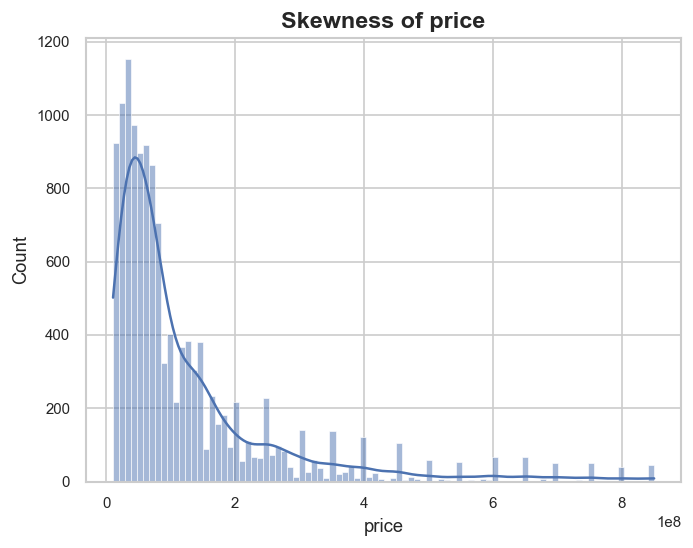

In [63]:
sns.histplot(df["price"], kde=True)
plt.title("Skewness of price")

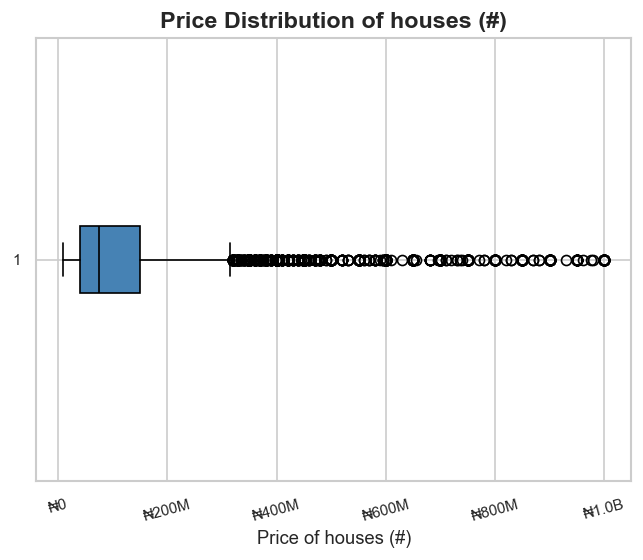

In [38]:
#Boxplot of prices after removing outliers
fig,ax = plt.subplots()
bp=plt.boxplot(x= df["price"], vert= False, patch_artist= True)
bp["boxes"][0].set_facecolor("steelblue")
bp["medians"][0].set_color("black")
ax.set_title("Price Distribution of houses (#)")
ax.set_xlabel("Price of houses (#)");
# remove scientific notation
ax=plt.gca()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(naira_format))
plt.xticks(rotation=15);
plt.savefig("../images/price_distribution_after_outlier_removal.png")

Outliers were checked in the **price** column since it is the target variable and most likely to contain extreme values.

A boxplot of the raw data revealed extreme outliers reaching up to ₦1.8 trillion, causing the entire distribution to be unreadable. These were almost certainly data entry errors or scraping artifacts.

To handle this, prices below the 1st percentile and above the 99th percentile were removed using a quantile filter. This brought the dataset from 13,888 rows down to 13,631 rows ,a loss of 257 records (2%).

The cleaned boxplot shows a median price of approximately ₦75M, with most properties falling between ₦38M and ₦155M. The distribution remains right-skewed, which is expected for real estate data with a large number of affordable properties with a long tail of luxury listings. However, log transform will be used in the modelling phase to correct this.


### Checking for high cardinality columns.

In [39]:
print("town:", df["town"].nunique(), "unique values")
print("title:", df["title"].nunique(), "unique values")

town: 180 unique values
title: 7 unique values


Town will excluded from model features due to high cardinality (189 unique values).State will be used instead as a higher-level geographic proxy.

## What is the Price Range of the Nigerian Property Market?

The Nigerian property market spans a wide price range. After removing extreme outliers, the median property price is ₦75M — meaning half of all listings fall below this price. Affordable properties start from around ₦38M (25th percentile), while luxury properties are priced above ₦155M (75th percentile). The most expensive legitimate listing in the dataset is ₦1.6B.

## What is the Average Cost of Entry?

The median property price in Nigeria is ₦75M, meaning half of all listings are priced below this point. Budget investors can enter the market from as low as ₦38M, while premium properties start from around ₦155M.

## Which states have the most active markets (based on the dataset)?


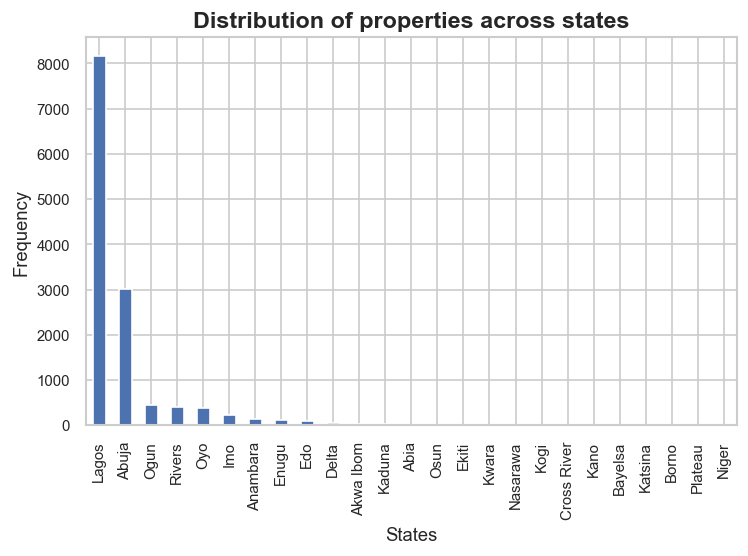

In [41]:
fig, ax= plt.subplots()
df["state"].value_counts().plot(kind= "bar", ax=ax)
ax.set_title("Distribution of properties across states")
ax.set_xlabel("States")
ax.set_ylabel("Frequency")
plt.tight_layout();
plt.savefig("../images/Distribution of properties across states.png")

The dataset is heavily concentrated in Lagos and Abuja, together accounting for most of the  listings. Most other states have fewer than 500 records, which may limit the model's predictive accuracy for those regions. 

## What type of property to build to maximize sales?

In [42]:
df["title"].value_counts()

title
Detached Duplex           6132
Terraced Duplexes         1971
Detached Bungalow         1676
Block of Flats            1453
Semi Detached Duplex      1408
Semi Detached Bungalow     368
Terraced Bungalow          147
Name: count, dtype: int64

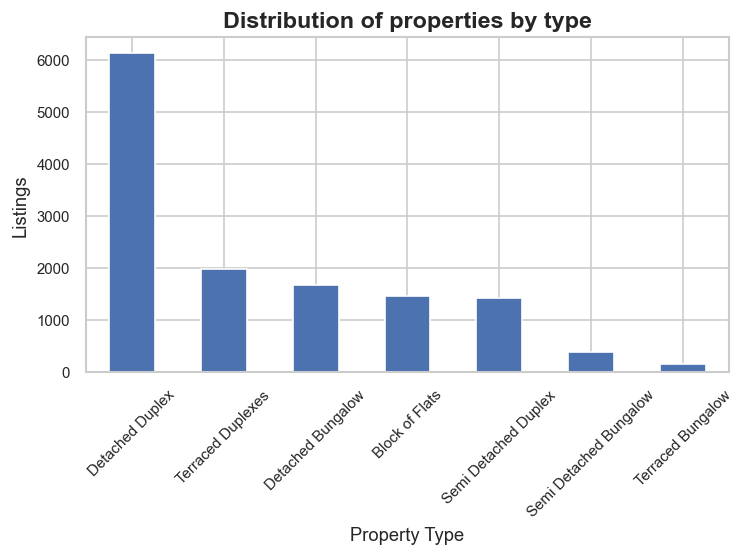

In [44]:
fig, ax= plt.subplots()
df["title"].value_counts().plot(kind= "bar", ax=ax)
ax.set_title("Distribution of properties by type")
ax.set_xlabel("Property Type")
ax.set_ylabel("Listings")
plt.xticks(rotation=45);
plt.tight_layout();
plt.savefig("../images/Distribution of properties by type.png")

While Detached Duplexes dominate with 6,335 listings, this also suggests a saturated market. Developers seeking less competition might consider Terraced Duplexes, Detached Bungalows, or Block of Flats, all showing healthy demand between 1,400–2,000 listings without the same level of market saturation.

## Where should i Invest?
We'll now look at average price by state to identify the best investment locations.

In [45]:
df.groupby("state")["price"].mean().sort_values(ascending=False).apply("{:,.0f}".format)

state
Abuja          157,824,935
Lagos          140,134,592
Borno          105,000,000
Abia            92,222,222
Anambara        91,591,118
Bayelsa         90,000,000
Delta           87,839,286
Rivers          81,033,610
Imo             75,042,035
Enugu           67,192,917
Ekiti           54,888,889
Edo             51,663,158
Oyo             48,416,237
Osun            46,977,778
Akwa Ibom       46,300,000
Nasarawa        44,142,857
Niger           40,000,000
Kaduna          34,772,727
Kogi            33,333,333
Kano            30,000,000
Ogun            29,013,560
Plateau         27,000,000
Cross River     25,000,000
Kwara           24,875,000
Katsina         15,000,000
Name: price, dtype: str

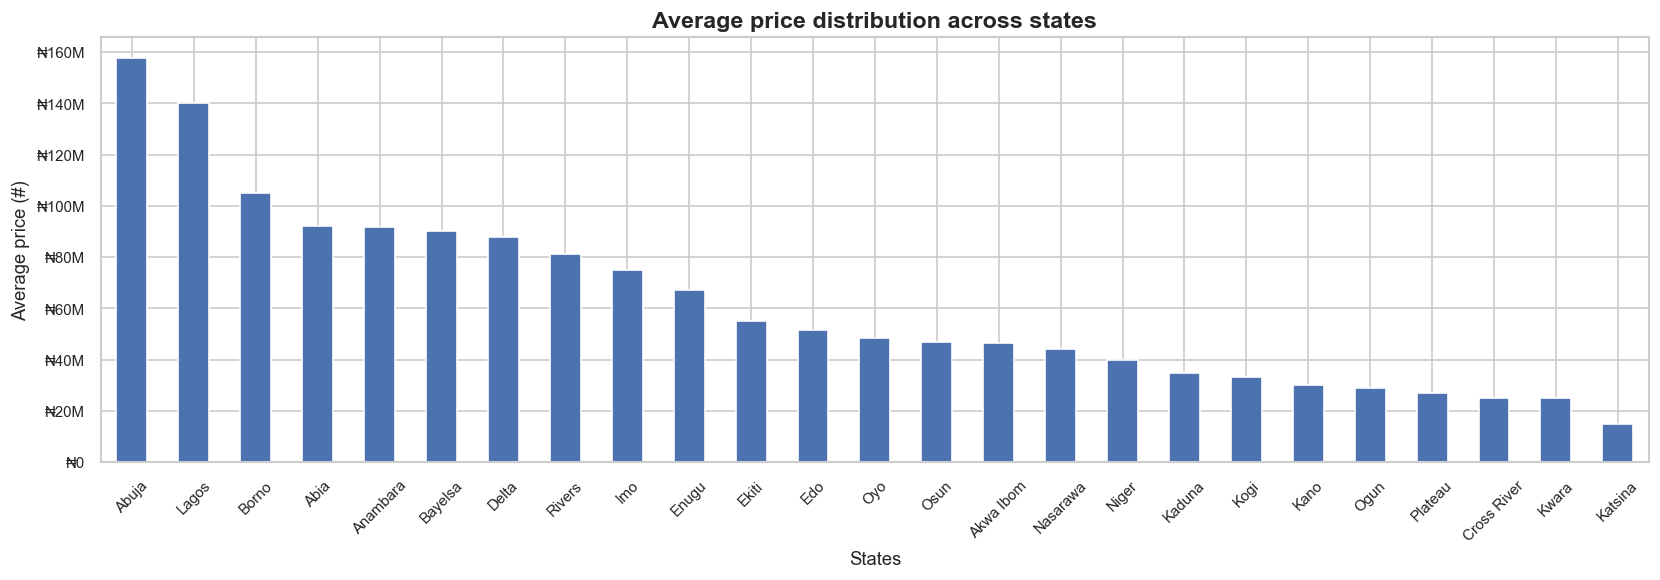

In [46]:
fig, ax = plt.subplots(figsize=(14,5))
df.groupby("state")["price"].mean().sort_values(ascending = False).plot(kind = "bar", ax= ax)
ax.set_title("Average price distribution across states")
ax.set_xlabel("States")
ax.set_ylabel("Average price (#)")
ax=plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(naira_format))
plt.xticks(rotation=45);
plt.tight_layout();
plt.savefig("../images/Average Price Distribution  across states.png")

Based on an investor's budget and strategy, the following should be taken into consideration.
**Abuja** has the highest average property prices, making it the premium investment destination for high-capital investors seeking strong returns. **Lagos**, while having more listings and a more active market, has a wider price range, making it better suited for investors seeking volume and variety. **Other states** present significantly lower prices but come with lower demand and higher risk.


## Which property type gives the best value?

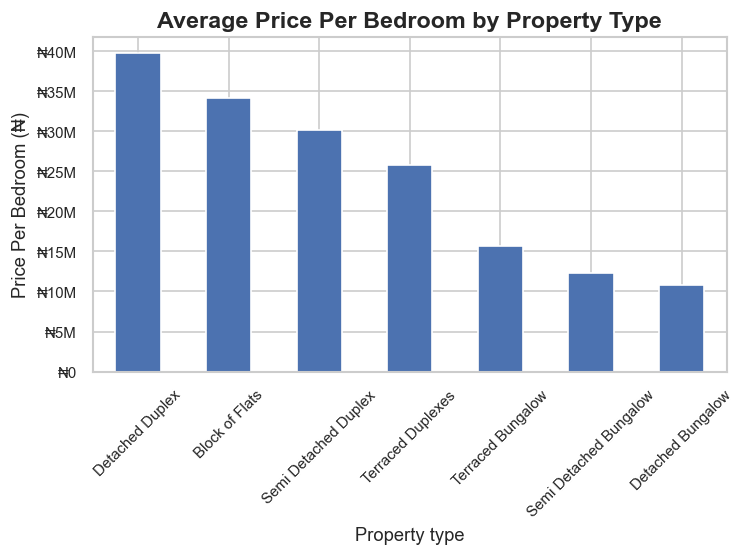

In [48]:
df["price_per_bedroom"]= df["price"]/df["bedrooms"]
fig, ax= plt.subplots()
(
    df.groupby("title")["price_per_bedroom"]
    .mean()
    .sort_values(ascending = False)
    .plot( kind="bar", ax=ax)
)
ax.set_title("Average Price Per Bedroom by Property Type")
ax.set_xlabel("Property type")
ax.set_ylabel("Price Per Bedroom (₦)")
ax=plt.gca()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(naira_format))
plt.xticks(rotation=45);
plt.tight_layout();
plt.savefig("../images/Average Price per Bedroom by property type.png")

Measuring value by price per bedroom, Detached Bungalows offer the best value at approximately ₦10M per bedroom — nearly 5x cheaper per bedroom than Detached Duplexes (₦48M per bedroom). 

For budget-conscious buyers, bungalows in general offer the most space for money. Detached Duplexes, while the most popular, are also the most expensive per bedroom making them a premium choice rather than a value one.

## Price Variation by state.

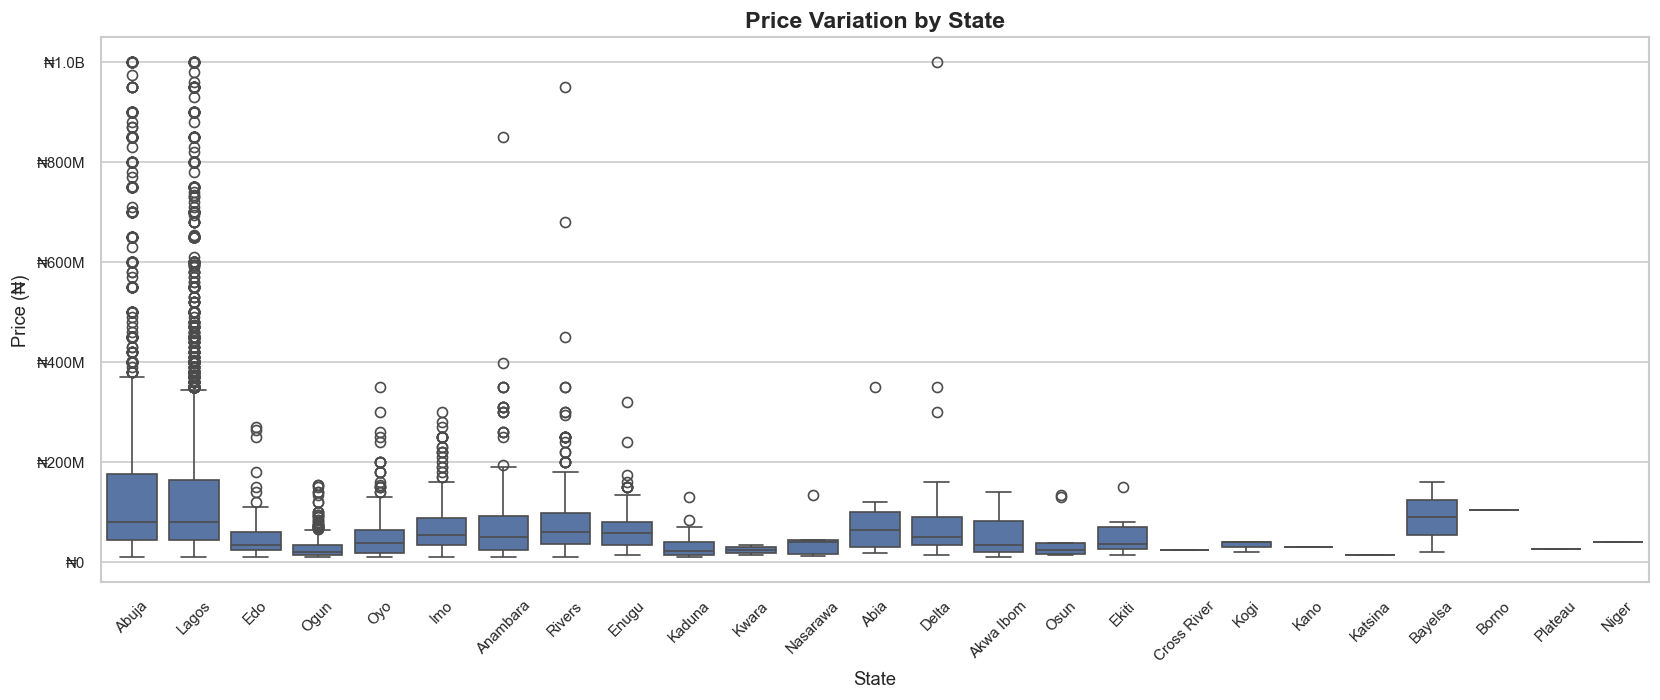

In [49]:
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df, x="state", y="price", ax=ax)
ax.set_title("Price Variation by State")
ax.set_xlabel("State")
ax.set_ylabel("Price (₦)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(naira_format))
plt.xticks(rotation=45)
plt.tight_layout();
plt.savefig("../images/Price Variation by state.png")

The boxplot shows significant price variation across states. Lagos and Abuja have the highest median prices and the widest distribution, indicating both premium and highly variable property markets. In contrast, most other states have lower and more tightly clustered prices, suggesting less market variability.

## Average price by property type


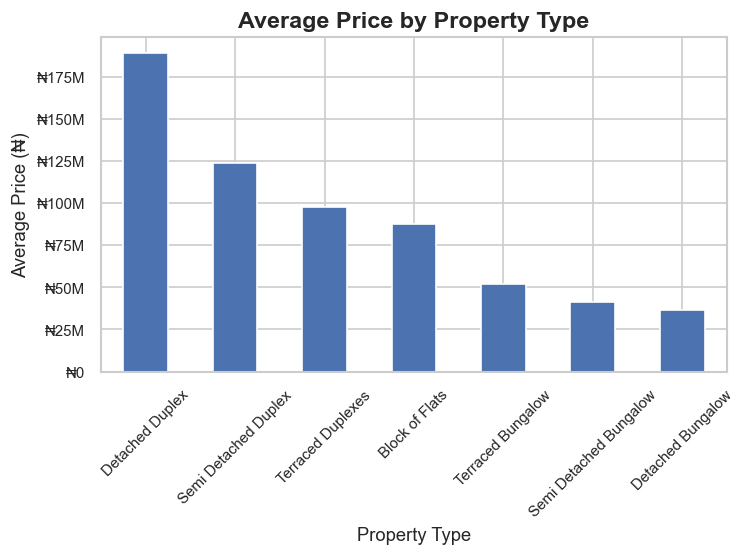

In [50]:
fig, ax = plt.subplots()
df.groupby("title")["price"].mean().sort_values(ascending=False).plot(kind="bar", ax=ax)
ax.set_title("Average Price by Property Type")
ax.set_xlabel("Property Type")
ax.set_ylabel("Average Price (₦)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(naira_format))
plt.xticks(rotation=45)
plt.tight_layout();
plt.savefig("../images/Average price by Property type.png")

The bar chart shows that detached duplex properties have the highest average prices, significantly outperforming other property types. Semi-detached duplexes follow, while bungalows are the most affordable. This indicates that property structure and size strongly influence pricing, making property type a key feature for predictive modeling.

## Which Locations Have the Most Demand?

We'll look at the top 20 towns by number of listings to identify 
where property demand is highest across Nigeria.

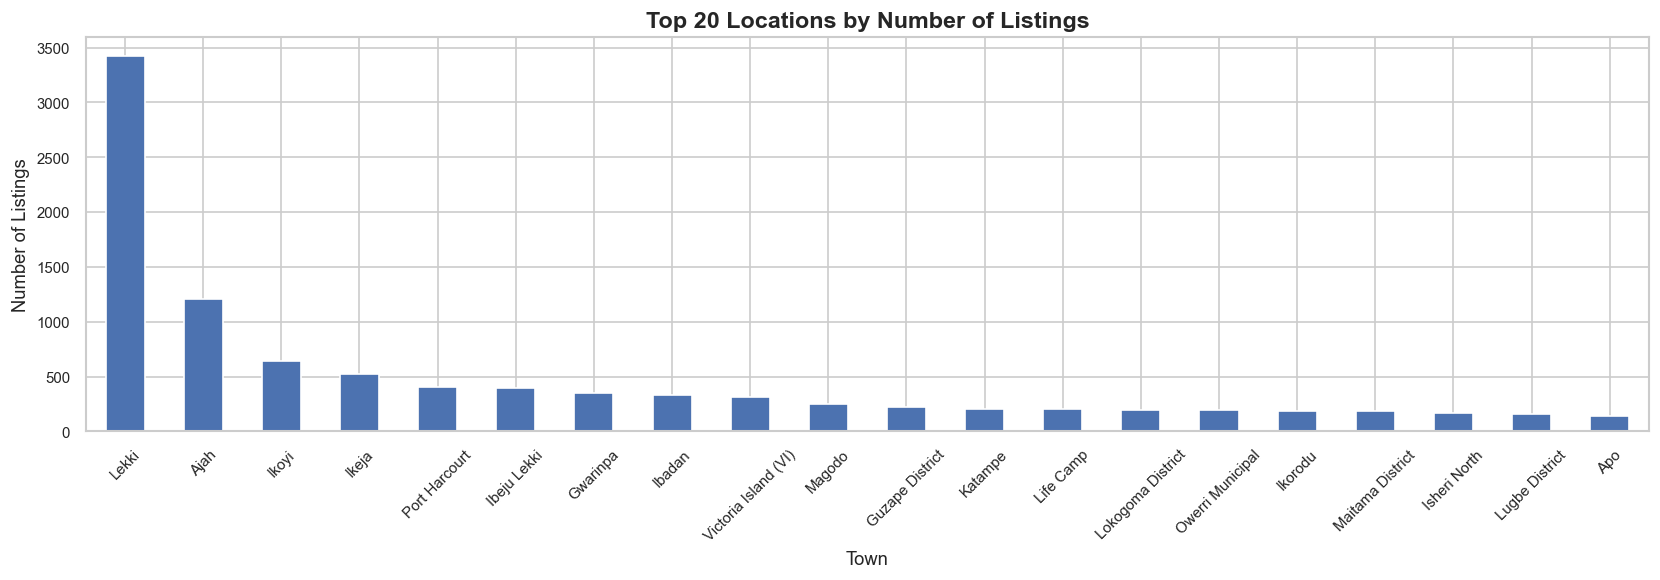

In [51]:
fig, ax = plt.subplots(figsize=(14, 5))
df["town"].value_counts().head(20).plot(kind="bar", ax=ax)
ax.set_title("Top 20 Locations by Number of Listings")
ax.set_xlabel("Town")
ax.set_ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.tight_layout();
plt.savefig("../images/Top 20 Locations by Number of listings.png")

Lekki is the most in-demand location in Nigeria with over 3,500 listings nearly 3x more than Ajah in second place. The top 5 locations are dominated by Lagos towns (Lekki, Ajah, Ikoyi, Ikeja), with Port Harcourt being the only non-Lagos entry in the top 5. For developers and investors, Lekki and Ajah represent the highest demand locations in the country and should be prioritized for new developments.

## Correlation Analysis

We examine how the numeric features in the dataset relate to each other 
and to price. This helps identify which features have the strongest 
influence on property prices.


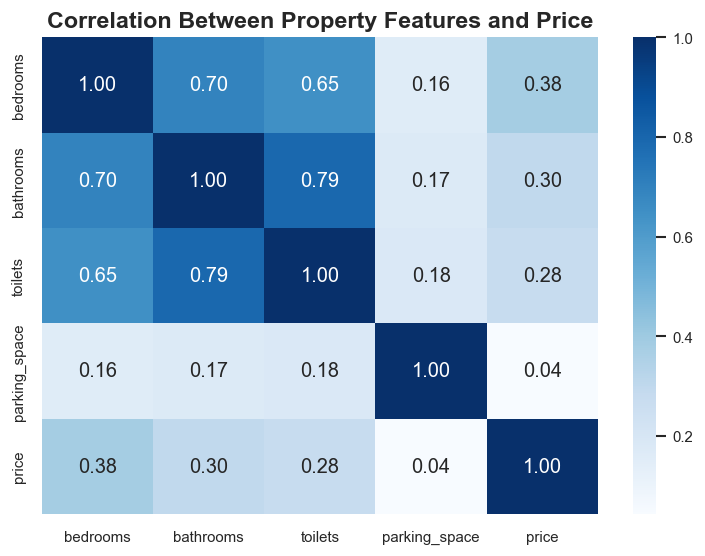

In [52]:
fig, ax = plt.subplots()
sns.heatmap(
    df[["bedrooms", "bathrooms", "toilets", "parking_space", "price"]].corr(),
    annot=True, fmt=".2f", cmap="Blues", ax=ax
)
ax.set_title("Correlation Between Property Features and Price")
plt.tight_layout();
plt.savefig("../images/Correlation Between Property Features and Price.png")

Bedrooms show the strongest correlation with price (0.35), making it the most useful numeric feature for price prediction. Parking space has almost no relationship with price (0.05) and will be dropped during modeling.

Bathrooms and toilets are highly correlated with each other (0.79), meaning only one will be included in the model to avoid multicollinearity.

## Price vs Number of Bedrooms

We visualize the relationship between the number of bedrooms and price 
to see if more bedrooms consistently leads to higher property prices.

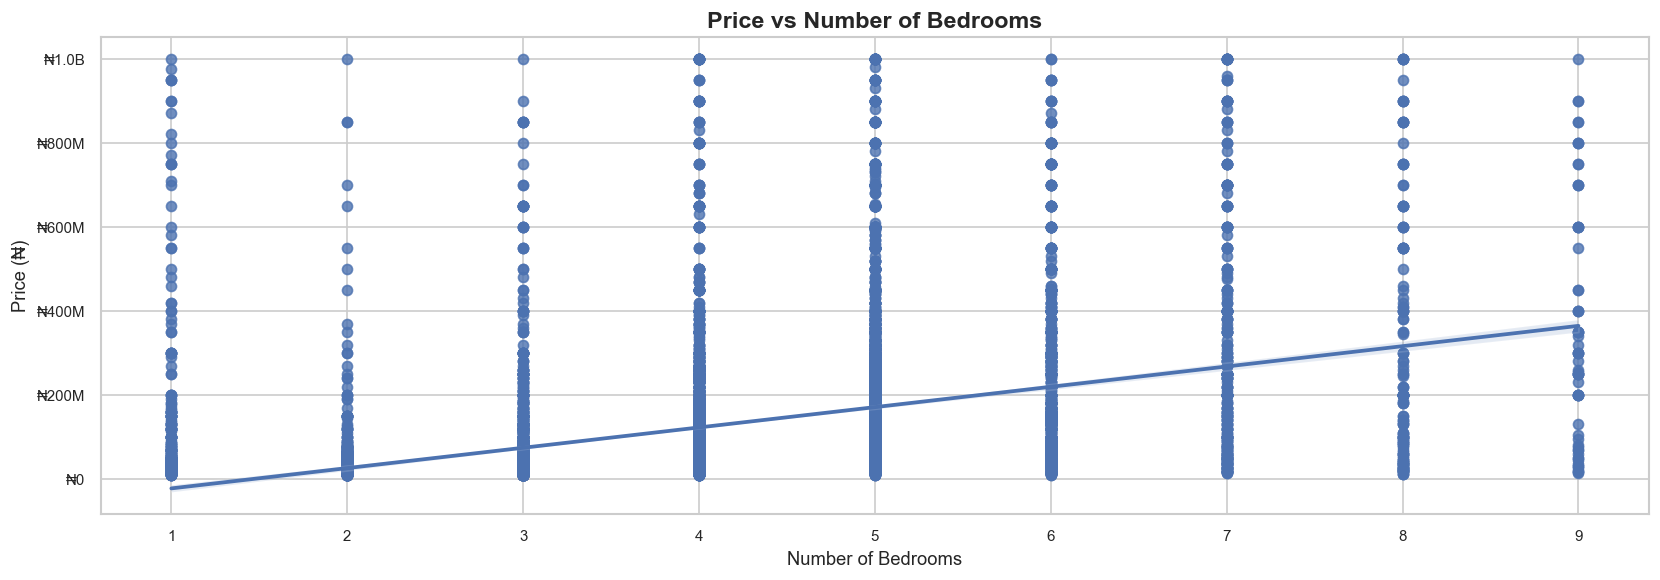

In [53]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.regplot(data=df, x="bedrooms", y="price", ax=ax)
ax.set_title("Price vs Number of Bedrooms")
ax.set_xlabel("Number of Bedrooms")
ax.set_ylabel("Price (₦)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(naira_format))
plt.tight_layout();
plt.savefig("../images/Price vs Number of Bedrooms.png")

While there is a general trend of higher prices with more bedrooms, the relationship is not strict. Properties of every bedroom count span a wide price range, suggesting that location and property type are stronger price drivers than bedroom count alone.
This is consistent with the correlation heatmap which showed only a moderate relationship (0.35) between bedrooms and price.

## 5. Key Findings & Recommendations

After analyzing over 13,000 Nigerian property listings, here is what the data reveals:

**Formal market bias** Listings are sourced from online platforms (Kaggle),  meaning informal and rural transactions are not captured. Prices skew higher than the true national average.

**The market is a tale of two cities.** Lagos and Abuja together account for 84% 
of all listings. If you're looking for volume and variety, Lagos is your market. 
If you're looking for premium returns, Abuja commands the highest average prices.

**Lekki is the heartbeat of Nigerian real estate.** With over 3,500 listings, 
it has nearly 3x more demand than the second most active town, Ajah. Any serious 
developer or investor should have Lekki on their radar.

**Detached Duplexes dominate but may be saturated.** They account for 6,335 
listings nearly 4x more than any other property type. Developers seeking less 
competition might find better opportunities in Terraced Duplexes or Block of Flats.

**Bungalows offer the best value for money.** At roughly ₦10M per bedroom, 
Detached Bungalows cost nearly 5x less per bedroom than Detached Duplexes. 
For budget-conscious buyers, bungalows offer the most space for money.

**The typical Nigerian property costs ₦75M.** Affordable entry starts around 
₦38M, while luxury properties begin at ₦155M and above.

**Bedroom count alone doesn't determine price.** The correlation between 
bedrooms and price is only 0.35, meaning location and property type are 
stronger price drivers than size alone. This is an important insight for 
the modeling phase.

 ## 6. Next Steps
- Price prediction model: Linear Regression  → Random Forest → XGBoost
- Deployment:interactive Streamlit price estimator